In [2]:
import os
import shutil

# ==========================================
# CONFIGURATION 
# ==========================================
JASMIN_DIR = "./Data/aef_solar_chips"

# 1. Ensure target subdirectories exist (Prevents destination crash)
pos_dir = os.path.join(JASMIN_DIR, "positives")
neg_dir = os.path.join(JASMIN_DIR, "negatives")
os.makedirs(pos_dir, exist_ok=True)
os.makedirs(neg_dir, exist_ok=True)

print(f"📂 Scanning '{JASMIN_DIR}' for new files to sort...")

# 2. Dynamically read the directory RIGHT NOW (Prevents stale memory crash)
current_files = [f for f in os.listdir(JASMIN_DIR) if f.endswith('.tif')]

pos_count, neg_count, unknown_count = 0, 0, 0

for filename in current_files:
    source_path = os.path.join(JASMIN_DIR, filename)
    
    # 3. Final safety check: ensure the file actually exists before moving
    if not os.path.isfile(source_path):
        continue
        
    # Sort based on your string prefixes
    if filename.startswith("POS_"):
        shutil.move(source_path, os.path.join(pos_dir, filename))
        pos_count += 1
    elif filename.startswith("NEG_"):
        shutil.move(source_path, os.path.join(neg_dir, filename))
        neg_count += 1
    else:
        unknown_count += 1
        print(f"  -> Left '{filename}' in root (couldn't determine pos/neg)")

print("\n==========================================")
print("🧹 HOUSEKEEPING COMPLETE")
print("==========================================")
print(f"New Positives moved: {pos_count:,}")
print(f"New Negatives moved: {neg_count:,}")
if unknown_count > 0:
    print(f"Files left in root: {unknown_count}")
print("==========================================")

📂 Scanning './Data/aef_solar_chips' for new files to sort...

🧹 HOUSEKEEPING COMPLETE
New Positives moved: 0
New Negatives moved: 39


Scanning image headers for physical dimensions...


Scanning Positives:   0%|          | 0/4965 [00:00<?, ?it/s]

Scanning Negatives:   0%|          | 0/1848 [00:00<?, ?it/s]


📏 PIXEL DIMENSION METRICS
POSITIVES (Solar Sites):
  Average: 419 x 414
  Median:  362 x 360
  Max:     2691 x 1741
  Min:     258 x 258

NEGATIVES (Background):
  Average: 264 x 264
  Max:     279 x 278



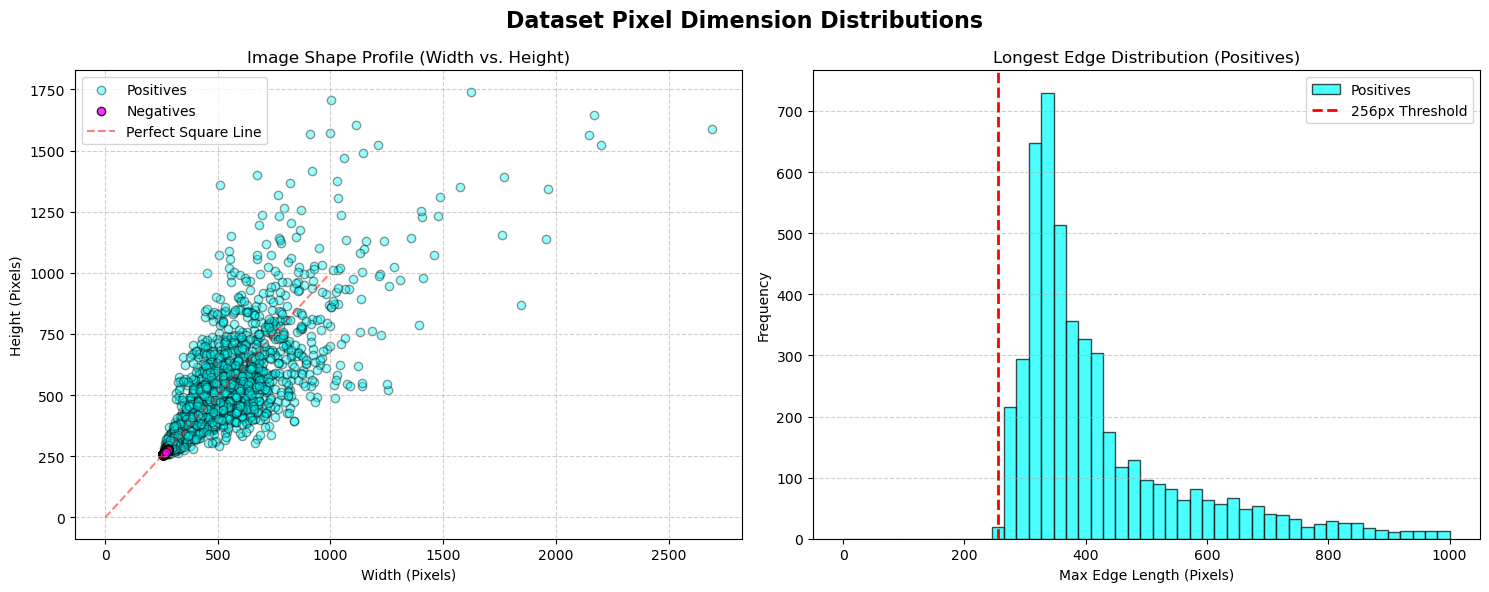

In [2]:
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

# ==========================================
# CONFIGURATION
# ==========================================
JASMIN_DIR = "./Data/aef_solar_chips"
pos_dir = os.path.join(JASMIN_DIR, "positives")
neg_dir = os.path.join(JASMIN_DIR, "negatives")

def get_dimensions(directory, desc):
    """Scans a directory and returns lists of widths and heights."""
    widths = []
    heights = []
    files = [f for f in os.listdir(directory) if f.endswith('.tif')]
    
    for filename in tqdm(files, desc=desc):
        try:
            with rasterio.open(os.path.join(directory, filename)) as src:
                # src.width and src.height read the metadata without loading the array
                widths.append(src.width)
                heights.append(src.height)
        except Exception as e:
            print(f"Failed to read {filename}: {e}")
            
    return np.array(widths), np.array(heights)

print("Scanning image headers for physical dimensions...")
pos_w, pos_h = get_dimensions(pos_dir, "Scanning Positives")
neg_w, neg_h = get_dimensions(neg_dir, "Scanning Negatives")

# Calculate the maximum edge for each image to understand the "bounding square"
pos_max_edge = np.maximum(pos_w, pos_h)
neg_max_edge = np.maximum(neg_w, neg_h)

# ==========================================
# PRINT METRICS
# ==========================================
print("\n==========================================")
print("📏 PIXEL DIMENSION METRICS")
print("==========================================")
print("POSITIVES (Solar Sites):")
print(f"  Average: {np.mean(pos_w):.0f} x {np.mean(pos_h):.0f}")
print(f"  Median:  {np.median(pos_w):.0f} x {np.median(pos_h):.0f}")
print(f"  Max:     {np.max(pos_w)} x {np.max(pos_h)}")
print(f"  Min:     {np.min(pos_w)} x {np.min(pos_h)}")

print("\nNEGATIVES (Background):")
print(f"  Average: {np.mean(neg_w):.0f} x {np.mean(neg_h):.0f}")
print(f"  Max:     {np.max(neg_w)} x {np.max(neg_h)}")
print("==========================================\n")

# ==========================================
# PLOT DISTRIBUTIONS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Dataset Pixel Dimension Distributions", fontsize=16, fontweight='bold')

# --- PANEL 1: Scatter Plot (Width vs Height) ---
axes[0].scatter(pos_w, pos_h, alpha=0.4, color='cyan', edgecolor='black', label="Positives")
axes[0].scatter(neg_w, neg_h, alpha=0.8, color='magenta', edgecolor='black', label="Negatives")
axes[0].plot([0, 1000], [0, 1000], 'r--', alpha=0.5, label="Perfect Square Line")
axes[0].set_title("Image Shape Profile (Width vs. Height)")
axes[0].set_xlabel("Width (Pixels)")
axes[0].set_ylabel("Height (Pixels)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- PANEL 2: Max Edge Distribution ---
# Zooming in on the 0-1000 pixel range to avoid the massive long-tail crushing the plot
bins = np.linspace(0, 1000, 50) 
axes[1].hist(pos_max_edge, bins=bins, color='cyan', edgecolor='black', alpha=0.7, label="Positives")
axes[1].axvline(256, color='red', linestyle='dashed', linewidth=2, label="256px Threshold")
axes[1].set_title("Longest Edge Distribution (Positives)")
axes[1].set_xlabel("Max Edge Length (Pixels)")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [4]:
pos_w[344]

np.int64(253)

In [3]:
bad = np.where(pos_h < 256)

In [4]:
np.size(bad)

0

In [6]:
np.min(pos_w)

np.int64(258)

In [1]:
import os
import geopandas as gpd
import math
from pyproj import Transformer
from shapely.ops import transform
from shapely.geometry import box

# ==========================================
# CONFIGURATION
# ==========================================
GPKG_FILE = "./Solar-Siting/global_solar_ml_pipeline.gpkg"
LAYER_NAME = "training_data_solar"
POS_DIR = "./Data/aef_solar_chips/positives"  # Ensure this points to your new subfolder

print(f"Loading '{LAYER_NAME}'...")
gdf = gpd.read_file(GPKG_FILE, layer=LAYER_NAME)

def get_utm_epsg_code(lon, lat):
    """Calculates the raw EPSG integer for the local UTM zone."""
    zone_number = math.floor((lon + 180) / 6) + 1
    return 32600 + zone_number if lat >= 0 else 32700 + zone_number

# ==========================================
# 🔍 SWEEP, INFLATE, AND DELETE
# ==========================================
print("Sweeping geometries for sub-256px dimensions...")

modified_count = 0
deleted_count = 0
new_geometries = []

for idx, row in gdf.iterrows():
    geom = row.geometry
    
    # 1. Project to Local UTM (Meters)
    centroid = geom.centroid
    lon, lat = centroid.x, centroid.y
    utm_epsg = get_utm_epsg_code(lon, lat)
    
    project_to_utm = Transformer.from_crs("EPSG:4326", f"EPSG:{utm_epsg}", always_xy=True).transform
    project_to_4326 = Transformer.from_crs(f"EPSG:{utm_epsg}", "EPSG:4326", always_xy=True).transform
    
    geom_utm = transform(project_to_utm, geom)
    
    # 2. Measure Metric Dimensions
    minx, miny, maxx, maxy = geom_utm.bounds
    width_m = maxx - minx
    height_m = maxy - miny
    
    # 2560 meters = 256 pixels at 10m/px scale
    MIN_METERS = 2560.0 
    
    if width_m < MIN_METERS or height_m < MIN_METERS:
        modified_count += 1
        
        # 3. Calculate Inflated Dimensions (Pad the short side, keep the long side)
        new_w = max(width_m, MIN_METERS)
        new_h = max(height_m, MIN_METERS)
        
        center_x = (minx + maxx) / 2.0
        center_y = (miny + maxy) / 2.0
        
        new_minx = center_x - (new_w / 2.0)
        new_maxx = center_x + (new_w / 2.0)
        new_miny = center_y - (new_h / 2.0)
        new_maxy = center_y + (new_h / 2.0)
        
        # 4. Create new box and project back to standard degrees
        new_box_utm = box(new_minx, new_miny, new_maxx, new_maxy)
        new_geom_4326 = transform(project_to_4326, new_box_utm)
        new_geometries.append(new_geom_4326)
        
        # 5. Reset tracking status
        if str(row['exported']).lower() == 'true':
            gdf.at[idx, 'exported'] = 'False'
            
            # 6. Delete the physical file on JASMIN
            filename = row['export_filename']
            filepath = os.path.join(POS_DIR, filename)
            
            if os.path.exists(filepath):
                os.remove(filepath)
                deleted_count += 1
    else:
        # Keep original if it passes the size check
        new_geometries.append(geom)

# Apply the updated geometries back to the dataframe
gdf.geometry = new_geometries

# ==========================================
# 💾 SAVE PROGRESS
# ==========================================
print("\n==========================================")
print("🛠️ INFLATION PROTOCOL COMPLETE")
print("==========================================")
print(f"Undersized Scenes Inflated: {modified_count}")
print(f"Stale .tif Files Deleted:   {deleted_count}")
print("==========================================")

print("\nOverwriting GeoPackage layer...")
gdf.to_file(GPKG_FILE, layer=LAYER_NAME, driver="GPKG")
print("✅ Database locked! You are clear to re-run the Earth Engine export script.")

Loading 'training_data_solar'...


ERROR 1: PROJ: proj_create_from_database: Open of /home/users/ar29/.conda/envs/solar-siting-ml/share/proj failed


Sweeping geometries for sub-256px dimensions...

🛠️ INFLATION PROTOCOL COMPLETE
Undersized Scenes Inflated: 432
Stale .tif Files Deleted:   35

Overwriting GeoPackage layer...
✅ Database locked! You are clear to re-run the Earth Engine export script.


Loading datasets...
Projecting to global Equal-Area metric grid (EPSG:6933) for accurate measuring...
Scanning all clusters for minimum edge distances...


  0%|          | 0/16040 [00:00<?, ?it/s]


📏 EDGE MARGIN AUDIT RESULTS
Absolute closest panel to any edge: 65.4 pixels
Average margin size: 138.9 pixels
Chips with panels closer than 100px to the edge: 1047



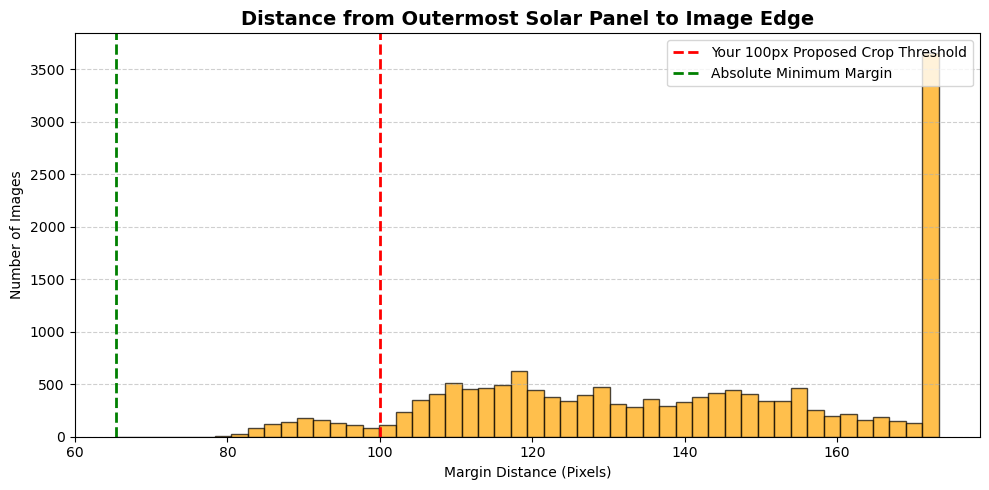

In [18]:
import geopandas as gpd
import ast
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

GPKG_FILE = "./Solar-Siting/global_solar_ml_pipeline.gpkg"

print("Loading datasets...")
boxes_gdf = gpd.read_file(GPKG_FILE, layer="training_data_solar")
polys_gdf = gpd.read_file(GPKG_FILE, layer="base_train")

print("Projecting to global Equal-Area metric grid (EPSG:6933) for accurate measuring...")
boxes_metric = boxes_gdf.to_crs("EPSG:6933")
polys_metric = polys_gdf.to_crs("EPSG:6933")

tightest_margins = []

print("Scanning all clusters for minimum edge distances...")
for idx, row in tqdm(boxes_metric.iterrows(), total=len(boxes_metric)):
    # 1. Parse the constituent IDs for this specific chip
    raw_ids = row['original_site_ids']
    constituent_ids = ast.literal_eval(raw_ids) if isinstance(raw_ids, str) else list(raw_ids)
    
    # 2. Isolate the exact solar polygons inside this chip
    cluster_polys = polys_metric[polys_metric['PV_ID'].isin(constituent_ids)]
    
    if cluster_polys.empty:
        continue
        
    # 3. Get the absolute outer boundaries
    box_bounds = row.geometry.bounds # [minx, miny, maxx, maxy]
    poly_bounds = cluster_polys.total_bounds # The tightest box around the solar panels
    
    # 4. Calculate the margin (in meters) on all four sides
    left_margin_m   = poly_bounds[0] - box_bounds[0]
    bottom_margin_m = poly_bounds[1] - box_bounds[1]
    right_margin_m  = box_bounds[2] - poly_bounds[2]
    top_margin_m    = box_bounds[3] - poly_bounds[3]
    
    # 5. Find the absolute tightest squeeze for this image
    min_margin_m = min(left_margin_m, bottom_margin_m, right_margin_m, top_margin_m)
    
    # 6. Convert meters to AlphaEarth pixels (10m/px)
    min_margin_px = min_margin_m / 10.0
    tightest_margins.append(min_margin_px)

tightest_margins = np.array(tightest_margins)

# ==========================================
# 📊 VISUALIZATION
# ==========================================
print("\n==========================================")
print("📏 EDGE MARGIN AUDIT RESULTS")
print("==========================================")
print(f"Absolute closest panel to any edge: {np.min(tightest_margins):.1f} pixels")
print(f"Average margin size: {np.mean(tightest_margins):.1f} pixels")

# Calculate how many chips would be ruined by a 100-pixel blind crop
danger_zone = np.sum(tightest_margins < 100)
print(f"Chips with panels closer than 100px to the edge: {danger_zone}")
print("==========================================\n")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tightest_margins, bins=50, color='orange', edgecolor='black', alpha=0.7)
ax.axvline(100, color='red', linestyle='dashed', linewidth=2, label="Your 100px Proposed Crop Threshold")
ax.axvline(np.min(tightest_margins), color='green', linestyle='dashed', linewidth=2, label="Absolute Minimum Margin")

ax.set_title("Distance from Outermost Solar Panel to Image Edge", fontsize=14, fontweight='bold')
ax.set_xlabel("Margin Distance (Pixels)")
ax.set_ylabel("Number of Images")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [17]:
import geopandas as gpd
import ast
from tqdm.notebook import tqdm

# ==========================================
# CONFIGURATION
# ==========================================
GPKG_FILE = "./Solar-Siting/global_solar_ml_pipeline.gpkg"
BOXES_LAYER = "training_data_solar"
POLYS_LAYER = "base_train"

print("Loading datasets...")
boxes_gdf = gpd.read_file(GPKG_FILE, layer=BOXES_LAYER)
polys_gdf = gpd.read_file(GPKG_FILE, layer=POLYS_LAYER)

print("Projecting to global metric grid (EPSG:6933) for accurate measurement...")
boxes_metric = boxes_gdf.to_crs("EPSG:6933")
polys_metric = polys_gdf.to_crs("EPSG:6933")

danger_total = 0
danger_downloaded = 0

print("Scanning clusters for < 100px margins and checking export status...")
for idx, row in tqdm(boxes_metric.iterrows(), total=len(boxes_metric)):
    # 1. Parse constituent IDs
    raw_ids = row['original_site_ids']
    constituent_ids = ast.literal_eval(raw_ids) if isinstance(raw_ids, str) else list(raw_ids)
    
    # 2. Get the actual solar polygons for this chip
    cluster_polys = polys_metric[polys_metric['PV_ID'].isin(constituent_ids)]
    if cluster_polys.empty:
        continue
        
    # 3. Calculate bounds and margins
    box_bounds = row.geometry.bounds
    poly_bounds = cluster_polys.total_bounds
    
    margins_m = [
        poly_bounds[0] - box_bounds[0], # Left
        poly_bounds[1] - box_bounds[1], # Bottom
        box_bounds[2] - poly_bounds[2], # Right
        box_bounds[3] - poly_bounds[3]  # Top
    ]
    
    min_margin_px = min(margins_m) / 10.0
    
    # 4. Check against your 100px threshold
    if min_margin_px < 120:
        danger_total += 1
        
        # Safely handle the 'exported' column (could be bool or string)
        if str(row['exported']).lower() == 'true':
            danger_downloaded += 1

# ==========================================
# 📊 AUDIT RESULTS
# ==========================================
print("\n==========================================")
print("🚨 DANGER ZONE AUDIT (Sub-100px Margin)")
print("==========================================")
print(f"Total clusters with < 100px margin: {danger_total:,}")
print(f"Of those, ALREADY DOWNLOADED:       {danger_downloaded:,}")
print(f"Not yet downloaded:                 {danger_total - danger_downloaded:,}")
print("==========================================")

Loading datasets...
Projecting to global metric grid (EPSG:6933) for accurate measurement...
Scanning clusters for < 100px margins and checking export status...


  0%|          | 0/16040 [00:00<?, ?it/s]


🚨 DANGER ZONE AUDIT (Sub-100px Margin)
Total clusters with < 100px margin: 4,851
Of those, ALREADY DOWNLOADED:       1,537
Not yet downloaded:                 3,314


In [16]:
import os
import geopandas as gpd
import ast
import math
from pyproj import Transformer
from shapely.ops import transform
from shapely.geometry import box
from tqdm.notebook import tqdm

# ==========================================
# CONFIGURATION
# ==========================================
GPKG_FILE = "./Solar-Siting/global_solar_ml_pipeline.gpkg"
BOXES_LAYER = "training_data_solar"
POLYS_LAYER = "base_train"
POS_DIR = "./Data/aef_solar_chips/positives"

print("Loading datasets...")
boxes_gdf = gpd.read_file(GPKG_FILE, layer=BOXES_LAYER)
polys_gdf = gpd.read_file(GPKG_FILE, layer=POLYS_LAYER)

def get_utm_epsg_code(lon, lat):
    """Calculates the raw EPSG integer for the local UTM zone."""
    zone_number = math.floor((lon + 180) / 6) + 1
    return 32600 + zone_number if lat >= 0 else 32700 + zone_number

# ==========================================
# 📐 AREA BASELINE
# ==========================================
print("Calculating original dataset area...")
original_area_sqkm = boxes_gdf.to_crs("EPSG:6933").geometry.area.sum() / 1e6

# ==========================================
# 🛠️ TWO-TIERED PURGE & ALIGNMENT
# ==========================================
print("\nExecuting 120px Purge and 150px Target Alignment...")

deleted_count = 0
padded_count = 0
new_geometries = []

for idx, row in tqdm(boxes_gdf.iterrows(), total=len(boxes_gdf)):
    geom = row.geometry
    is_exported = str(row['exported']).lower() == 'true'
    
    raw_ids = row['original_site_ids']
    constituent_ids = ast.literal_eval(raw_ids) if isinstance(raw_ids, str) else list(raw_ids)
    
    cluster_polys = polys_gdf[polys_gdf['PV_ID'].isin(constituent_ids)]
    
    if cluster_polys.empty:
        new_geometries.append(geom)
        continue
        
    # Project to metric grid
    centroid = geom.centroid
    utm_epsg = get_utm_epsg_code(centroid.x, centroid.y)
    
    project_to_utm = Transformer.from_crs("EPSG:4326", f"EPSG:{utm_epsg}", always_xy=True).transform
    project_to_4326 = Transformer.from_crs(f"EPSG:{utm_epsg}", "EPSG:4326", always_xy=True).transform
    
    geom_utm = transform(project_to_utm, geom)
    polys_utm = cluster_polys.to_crs(f"EPSG:{utm_epsg}")
    
    # Extract bounds
    minx_b, miny_b, maxx_b, maxy_b = geom_utm.bounds
    minx_p, miny_p, maxx_p, maxy_p = polys_utm.total_bounds
    
    # Check margins (meters)
    left_m = minx_p - minx_b
    bottom_m = miny_p - miny_b
    right_m = maxx_b - maxx_p
    top_m = maxy_b - maxy_p
    
    min_margin_m = min(left_m, bottom_m, right_m, top_m)
    
    needs_padding = False
    
    # -- TIER 1: The 120px Purge Rule for Downloaded Data --
    if is_exported and min_margin_m < 1200.0:
        boxes_gdf.at[idx, 'exported'] = 'False'
        is_exported = False  # Update so it gets caught by the padding logic below
        
        filename = row['export_filename']
        filepath = os.path.join(POS_DIR, filename)
        if os.path.exists(filepath):
            os.remove(filepath)
            deleted_count += 1
            
        needs_padding = True
        
    # -- TIER 2: The 150px Padding Rule for Un-downloaded Data --
    elif not is_exported and min_margin_m < 1500.0:
        needs_padding = True
        
    # -- APPLY PADDING IF FLAGGED --
    if needs_padding:
        TARGET_MARGIN = 1500.0
        
        # Bring ONLY the necessary walls exactly up to the 1500m target
        if left_m < TARGET_MARGIN:
            minx_b = minx_p - TARGET_MARGIN
        if bottom_m < TARGET_MARGIN:
            miny_b = miny_p - TARGET_MARGIN
        if right_m < TARGET_MARGIN:
            maxx_b = maxx_p + TARGET_MARGIN
        if top_m < TARGET_MARGIN:
            maxy_b = maxy_p + TARGET_MARGIN
            
        padded_count += 1
        
        # Project back to degrees
        new_box_utm = box(minx_b, miny_b, maxx_b, maxy_b)
        new_geom_4326 = transform(project_to_4326, new_box_utm)
        new_geometries.append(new_geom_4326)
    else:
        # Scene is safe (either downloaded & >120px, or undownloaded & >150px)
        new_geometries.append(geom)

boxes_gdf.geometry = new_geometries

# ==========================================
# 📊 NEW AREA CALCULATION
# ==========================================
print("\nCalculating new dataset area...")
new_area_sqkm = boxes_gdf.to_crs("EPSG:6933").geometry.area.sum() / 1e6
area_difference = new_area_sqkm - original_area_sqkm

print("\n==========================================")
print("🛠️ HYBRID PURGE & ALIGNMENT COMPLETE")
print("==========================================")
print(f"Sub-120px Files Deleted:        {deleted_count}")
print(f"Un-exported Scenes Padded:      {padded_count}")
print("------------------------------------------")
print(f"Original Area:                  {original_area_sqkm:,.2f} sq km")
print(f"New Area:                       {new_area_sqkm:,.2f} sq km")
print(f"Total Area Added:               +{area_difference:,.2f} sq km")
print("==========================================")

print("\nOverwriting GeoPackage layer...")
boxes_gdf.to_file(GPKG_FILE, layer=BOXES_LAYER, driver="GPKG")
print("✅ Database locked! Safe to restart your Earth Engine pipeline.")

Loading datasets...
Calculating original dataset area...

Executing 120px Purge and 150px Target Alignment...


  0%|          | 0/16040 [00:00<?, ?it/s]


Calculating new dataset area...

🛠️ HYBRID PURGE & ALIGNMENT COMPLETE
Sub-120px Files Deleted:        18
Un-exported Scenes Padded:      4209
------------------------------------------
Original Area:                  327,703.32 sq km
New Area:                       340,516.43 sq km
Total Area Added:               +12,813.11 sq km

Overwriting GeoPackage layer...
✅ Database locked! Safe to restart your Earth Engine pipeline.


In [19]:
import os
import geopandas as gpd
import ast
import math
from pyproj import Transformer
from shapely.ops import transform
from shapely.geometry import box
from tqdm.notebook import tqdm

# ==========================================
# 1. CORRECTED CONFIGURATION
# ==========================================
GPKG_FILE = "./Solar-Siting/global_solar_ml_pipeline.gpkg"
BOXES_LAYER = "training_data_solar"  # Corrected Layer!
POLYS_LAYER = "base_train"
POS_DIR = "./Data/aef_solar_chips/positives"

print(f"Loading '{BOXES_LAYER}'...")
boxes_gdf = gpd.read_file(GPKG_FILE, layer=BOXES_LAYER)
polys_gdf = gpd.read_file(GPKG_FILE, layer=POLYS_LAYER)

def get_utm_epsg_code(lon, lat):
    """Calculates the raw EPSG integer for the local UTM zone."""
    zone_number = math.floor((lon + 180) / 6) + 1
    return 32600 + zone_number if lat >= 0 else 32700 + zone_number

# ==========================================
# 2. AREA BASELINE
# ==========================================
print("Calculating original dataset area (via EPSG:6933)...")
original_area_sqkm = boxes_gdf.to_crs("EPSG:6933").geometry.area.sum() / 1e6

# ==========================================
# 3. HYBRID PURGE & ALIGNMENT (UTM MATH)
# ==========================================
print("\nExecuting True 120px Purge and 150px Alignment...")

deleted_count = 0
padded_count = 0
new_geometries = []

for idx, row in tqdm(boxes_gdf.iterrows(), total=len(boxes_gdf)):
    geom = row.geometry
    is_exported = str(row['exported']).lower() == 'true'
    
    raw_ids = row['original_site_ids']
    constituent_ids = ast.literal_eval(raw_ids) if isinstance(raw_ids, str) else list(raw_ids)
    
    cluster_polys = polys_gdf[polys_gdf['PV_ID'].isin(constituent_ids)]
    
    if cluster_polys.empty:
        new_geometries.append(geom)
        continue
        
    # Project to true local UTM for accurate distance measurement
    centroid = geom.centroid
    utm_epsg = get_utm_epsg_code(centroid.x, centroid.y)
    
    project_to_utm = Transformer.from_crs("EPSG:4326", f"EPSG:{utm_epsg}", always_xy=True).transform
    project_to_4326 = Transformer.from_crs(f"EPSG:{utm_epsg}", "EPSG:4326", always_xy=True).transform
    
    geom_utm = transform(project_to_utm, geom)
    polys_utm = cluster_polys.to_crs(f"EPSG:{utm_epsg}")
    
    # Extract bounds
    minx_b, miny_b, maxx_b, maxy_b = geom_utm.bounds
    minx_p, miny_p, maxx_p, maxy_p = polys_utm.total_bounds
    
    # Check true linear margins (meters)
    left_m = minx_p - minx_b
    bottom_m = miny_p - miny_b
    right_m = maxx_b - maxx_p
    top_m = maxy_b - maxy_p
    
    min_margin_m = min(left_m, bottom_m, right_m, top_m)
    
    needs_padding = False
    
    # -- TIER 1: 120px Purge for Downloaded --
    if is_exported and min_margin_m < 1200.0:
        boxes_gdf.at[idx, 'exported'] = 'False'
        is_exported = False  
        
        filename = row['export_filename']
        filepath = os.path.join(POS_DIR, filename)
        if os.path.exists(filepath):
            os.remove(filepath)
            deleted_count += 1
            
        needs_padding = True
        
    # -- TIER 2: 150px Padding for Un-downloaded --
    elif not is_exported and min_margin_m < 1500.0:
        needs_padding = True
        
    # -- APPLY TARGETED PADDING --
    if needs_padding:
        TARGET_MARGIN = 1500.0
        
        if left_m < TARGET_MARGIN:
            minx_b = minx_p - TARGET_MARGIN
        if bottom_m < TARGET_MARGIN:
            miny_b = miny_p - TARGET_MARGIN
        if right_m < TARGET_MARGIN:
            maxx_b = maxx_p + TARGET_MARGIN
        if top_m < TARGET_MARGIN:
            maxy_b = maxy_p + TARGET_MARGIN
            
        padded_count += 1
        
        # Project new UTM box back to degrees
        new_box_utm = box(minx_b, miny_b, maxx_b, maxy_b)
        new_geom_4326 = transform(project_to_4326, new_box_utm)
        new_geometries.append(new_geom_4326)
    else:
        new_geometries.append(geom)

boxes_gdf.geometry = new_geometries

# ==========================================
# 4. REPORTING
# ==========================================
print("\nCalculating new dataset area...")
new_area_sqkm = boxes_gdf.to_crs("EPSG:6933").geometry.area.sum() / 1e6
area_difference = new_area_sqkm - original_area_sqkm

print("\n==========================================")
print("🛠️ TRUE HYBRID PURGE & ALIGNMENT COMPLETE")
print("==========================================")
print(f"Sub-120px Files Deleted:        {deleted_count}")
print(f"Un-exported Scenes Padded:      {padded_count}")
print("------------------------------------------")
print(f"Original Area:                  {original_area_sqkm:,.2f} sq km")
print(f"New Area:                       {new_area_sqkm:,.2f} sq km")
print(f"Total Area Added:               +{area_difference:,.2f} sq km")
print("==========================================")

print("\nOverwriting GeoPackage layer...")
boxes_gdf.to_file(GPKG_FILE, layer=BOXES_LAYER, driver="GPKG")
print("✅ Database locked on true target layer!")

Loading 'training_data_solar'...
Calculating original dataset area (via EPSG:6933)...

Executing True 120px Purge and 150px Alignment...


  0%|          | 0/16040 [00:00<?, ?it/s]


Calculating new dataset area...

🛠️ TRUE HYBRID PURGE & ALIGNMENT COMPLETE
Sub-120px Files Deleted:        0
Un-exported Scenes Padded:      1744
------------------------------------------
Original Area:                  340,516.43 sq km
New Area:                       340,516.43 sq km
Total Area Added:               +0.00 sq km

Overwriting GeoPackage layer...
✅ Database locked on true target layer!


Loading datasets...
Scanning clusters using precise local UTM projections...


  0%|          | 0/16040 [00:00<?, ?it/s]


📏 TRUE EDGE MARGIN AUDIT RESULTS (UTM)
Absolute closest panel to any edge: 120.0 pixels
Average margin size: 161.8 pixels
Chips with panels closer than 100px to the edge: 0



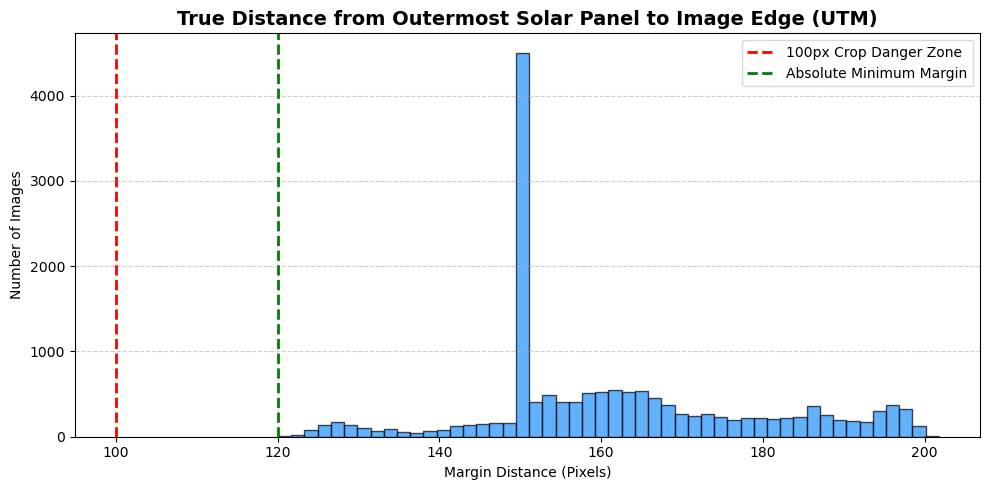

In [20]:
import geopandas as gpd
import ast
import numpy as np
import matplotlib.pyplot as plt
import math
from pyproj import Transformer
from shapely.ops import transform
from tqdm.notebook import tqdm

# ==========================================
# CONFIGURATION
# ==========================================
GPKG_FILE = "./Solar-Siting/global_solar_ml_pipeline.gpkg"
BOXES_LAYER = "training_data_solar"
POLYS_LAYER = "base_train"

print("Loading datasets...")
boxes_gdf = gpd.read_file(GPKG_FILE, layer=BOXES_LAYER)
polys_gdf = gpd.read_file(GPKG_FILE, layer=POLYS_LAYER)

def get_utm_epsg_code(lon, lat):
    """Calculates the raw EPSG integer for the local UTM zone."""
    zone_number = math.floor((lon + 180) / 6) + 1
    return 32600 + zone_number if lat >= 0 else 32700 + zone_number

tightest_margins = []

print("Scanning clusters using precise local UTM projections...")
for idx, row in tqdm(boxes_gdf.iterrows(), total=len(boxes_gdf)):
    geom = row.geometry
    raw_ids = row['original_site_ids']
    constituent_ids = ast.literal_eval(raw_ids) if isinstance(raw_ids, str) else list(raw_ids)
    
    cluster_polys = polys_gdf[polys_gdf['PV_ID'].isin(constituent_ids)]
    if cluster_polys.empty:
        continue
        
    # Project to local metric UTM
    centroid = geom.centroid
    utm_epsg = get_utm_epsg_code(centroid.x, centroid.y)
    
    project_to_utm = Transformer.from_crs("EPSG:4326", f"EPSG:{utm_epsg}", always_xy=True).transform
    
    geom_utm = transform(project_to_utm, geom)
    polys_utm = cluster_polys.to_crs(f"EPSG:{utm_epsg}")
    
    # Extract true metric bounds
    minx_b, miny_b, maxx_b, maxy_b = geom_utm.bounds
    minx_p, miny_p, maxx_p, maxy_p = polys_utm.total_bounds
    
    # Calculate margin in meters
    left_m = minx_p - minx_b
    bottom_m = miny_p - miny_b
    right_m = maxx_b - maxx_p
    top_m = maxy_b - maxy_p
    
    min_margin_m = min(left_m, bottom_m, right_m, top_m)
    
    # Convert true meters to AlphaEarth pixels (10m/px)
    min_margin_px = min_margin_m / 10.0
    tightest_margins.append(min_margin_px)

tightest_margins = np.array(tightest_margins)

# ==========================================
# 📊 VISUALIZATION
# ==========================================
print("\n==========================================")
print("📏 TRUE EDGE MARGIN AUDIT RESULTS (UTM)")
print("==========================================")
print(f"Absolute closest panel to any edge: {np.min(tightest_margins):.1f} pixels")
print(f"Average margin size: {np.mean(tightest_margins):.1f} pixels")

danger_zone = np.sum(tightest_margins < 150)
print(f"Chips with panels closer than 100px to the edge: {danger_zone}")
print("==========================================\n")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tightest_margins, bins=50, color='dodgerblue', edgecolor='black', alpha=0.7)
ax.axvline(100, color='red', linestyle='dashed', linewidth=2, label="100px Crop Danger Zone")
ax.axvline(np.min(tightest_margins), color='green', linestyle='dashed', linewidth=2, label="Absolute Minimum Margin")

ax.set_title("True Distance from Outermost Solar Panel to Image Edge (UTM)", fontsize=14, fontweight='bold')
ax.set_xlabel("Margin Distance (Pixels)")
ax.set_ylabel("Number of Images")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Scanning chipped directory...

📊 CHIP DISTRIBUTION AUDIT
Unique Original Scenes: 16,053
Total Chips Generated:  82,148



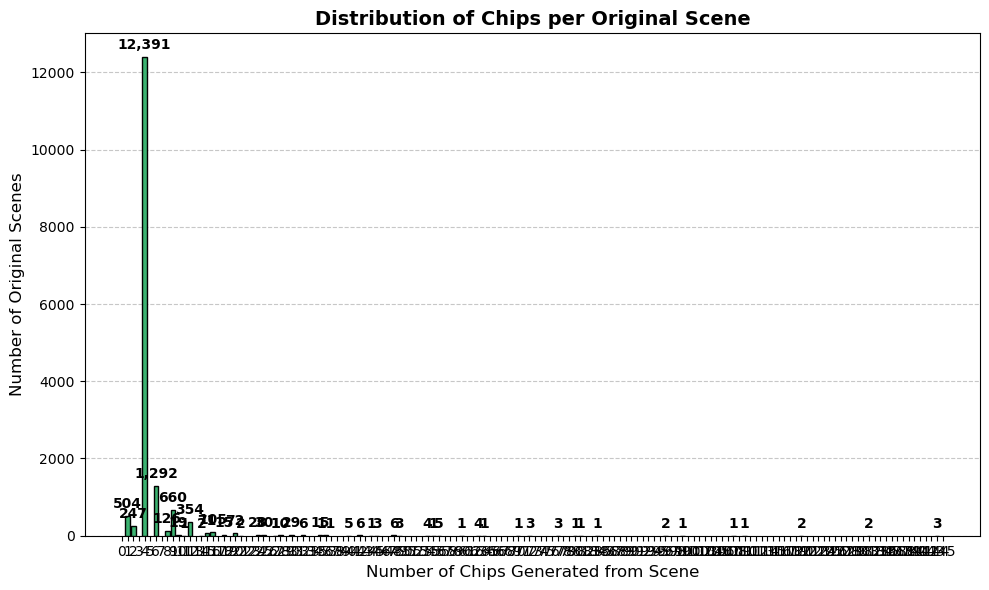

In [1]:
import os
import collections
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
CHIPS_DIR = "./Data/aef_solar_chips/positives/chips"

print("Scanning chipped directory...")

try:
    chip_files = [f for f in os.listdir(CHIPS_DIR) if f.endswith('.tif')]
except FileNotFoundError:
    print(f"Error: Directory not found -> {CHIPS_DIR}")
    chip_files = []

# Dictionary to track how many chips each base scene produced
scene_tracker = collections.Counter()

for filename in chip_files:
    # 1. Strip the '.tif' extension
    name_no_ext = filename[:-4]
    
    # 2. Split by the VERY LAST underscore 
    # Example: 'POS_MEX_10_2018_4' -> ['POS_MEX_10_2018', '4']
    parts = name_no_ext.rsplit('_', 1)
    
    if len(parts) == 2 and parts[1].isdigit():
        base_scene_name = parts[0]
        scene_tracker[base_scene_name] += 1
    else:
        print(f"Warning: Ignored uniquely formatted file: {filename}")

# ==========================================
# CALCULATE METRICS
# ==========================================
total_unique_scenes = len(scene_tracker)
total_chips = sum(scene_tracker.values())

print("\n==========================================")
print("📊 CHIP DISTRIBUTION AUDIT")
print("==========================================")
print(f"Unique Original Scenes: {total_unique_scenes:,}")
print(f"Total Chips Generated:  {total_chips:,}")
print("==========================================\n")

# ==========================================
# PLOT DISTRIBUTION
# ==========================================
if total_unique_scenes > 0:
    # Extract just the raw counts (e.g., [4, 1, 4, 9, 1...])
    chip_counts = list(scene_tracker.values())
    
    # Count how many scenes had 1 chip, 4 chips, etc.
    distribution = collections.Counter(chip_counts)
    
    x_vals = sorted(distribution.keys())
    y_vals = [distribution[x] for x in x_vals]
    
    plt.figure(figsize=(10, 6))
    
    # Create a bar chart for discrete integer frequencies
    bars = plt.bar(x_vals, y_vals, color='mediumseagreen', edgecolor='black', zorder=3)
    
    plt.title("Distribution of Chips per Original Scene", fontsize=14, fontweight='bold')
    plt.xlabel("Number of Chips Generated from Scene", fontsize=12)
    plt.ylabel("Number of Original Scenes", fontsize=12)
    
    # Ensure the x-axis only shows the integer ticks that actually exist
    plt.xticks(range(0, max(x_vals) + 2))
    plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
    
    # Add exact numeric labels to the top of each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (max(y_vals)*0.01), 
                 f"{int(yval):,}", ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No chips found to analyze.")

In [2]:
print(max(x_vals))

77
